# Measuring all of it

Notebook 09 asked where to throw to measure a player, and answered for **one** number: the
isotropic $\sigma$. The model has since grown a shape (12), a pull (13) and a lean (16), and
the design question has not caught up. This notebook asks it properly, of all five
parameters at once:

$$\theta = (b_x,\ b_y,\ \Sigma_{xx},\ \Sigma_{xy},\ \Sigma_{yy})$$

Two versions, which sound alike and are not:

* **"Measure me best."** Minimise the joint uncertainty in $\theta$ -- classical
  **D-optimality**, the volume of the confidence ellipsoid.
* **"Make me score best."** Minimise the *visits per leg* I lose to residual uncertainty.
  The parameters do not matter equally to the policy, so this is a different criterion and,
  it turns out, a different design.

Then the second half of the question: given a session is a thing you have to arrange, can
any of this be learned during **normal play** instead -- as $\sigma$ and the pull can -- and
is it worth trying?

In [1]:
import os
import sys
import time
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.design import (candidate_targets, c_criterion, certificate_general,
                          information_at_points, information_maps, l_criterion,
                          optimal_design_general, sigma_gradient)
from darts.throw_shape import (ParticleThrowPosterior, ShapeRecommender,
                               correlation, play_leg, sigma_matrices)
from darts.utils import aim_description, mm_per_pixel

PX = 256
BOARD, CHECKOUTS = generate_dartboard(PX)
MM = mm_per_pixel(PX)
CENTRE = PX // 2
PARAMS = ('b_x', 'b_y', 'S_xx', 'S_xy', 'S_yy')

# the player throughout: mildly tall, mildly leaning, league-ish overall
SX, SY, RHO = 14.0, 18.0, 0.2
S_TRUE = np.array([[SX ** 2, RHO * SX * SY], [RHO * SX * SY, SY ** 2]])
print(f'sigma_x {SX}, sigma_y {SY}, rho {RHO}  '
      f'(isotropic equivalent {np.sqrt(np.trace(S_TRUE)/2):.1f} mm)')

maps = information_maps(PX, S_TRUE, board=BOARD)
CAND = candidate_targets(PX, point_stride=2)
I_PTS = information_at_points(maps, CAND)
print(f'{len(CAND)} candidate targets')

sigma_x 14.0, sigma_y 18.0, rho 0.2  (isotropic equivalent 16.1 mm)


7305 candidate targets


## What each parameter is actually worth

Before designing anything: the parameters are not equally important, and a design that does
not know that will spend darts in the wrong place.

`scripts/decision_weight.py` measures it directly. For a perturbation $\delta$ of the
believed parameters, it simulates legs in which the *policy* comes from $\theta + \delta$
while the *world* is $\theta$, and records the visits lost. That loss is zero at
$\delta = 0$ and non-negative everywhere, so it is locally quadratic, and its Hessian $H$
is the weight matrix the design needs:

$$\mathbb{E}[\text{visits lost}] \;\approx\; \tfrac{1}{2}\,\mathrm{tr}\!\left(H\,M(w)^{-1}\right) / n$$

Minimising that is the **L-criterion**, $\mathrm{tr}(W M^{-1})$ with $W = H$ -- the same
family that contains c-optimality ($W = cc^\top$) and A-optimality ($W = I$).

In [2]:
dw = np.load(os.path.join(module_path, 'results', 'design', 'decision_weight.npz'))
H = dw['H_psd']
step = dw['step']
print(f"estimated from {int(dw['legs'])} legs per evaluation")

pd.DataFrame({
    'a meaningful error': ['3 mm of sideways pull', '3 mm of vertical pull',
                           '1.5 mm on sigma_x', '0.15 of correlation',
                           '1.5 mm on sigma_y'],
    'visits lost per leg': [0.5 * H[i, i] * step[i] ** 2 for i in range(5)],
}, index=PARAMS).round(4)

estimated from 200 legs per evaluation


,a meaningful error,visits lost per leg
b_x,3 mm of sideways pull,0.1389
b_y,3 mm of vertical pull,0.0658
S_xx,1.5 mm on sigma_x,0.0092
S_xy,0.15 of correlation,0.0121
S_yy,1.5 mm on sigma_y,0.0064


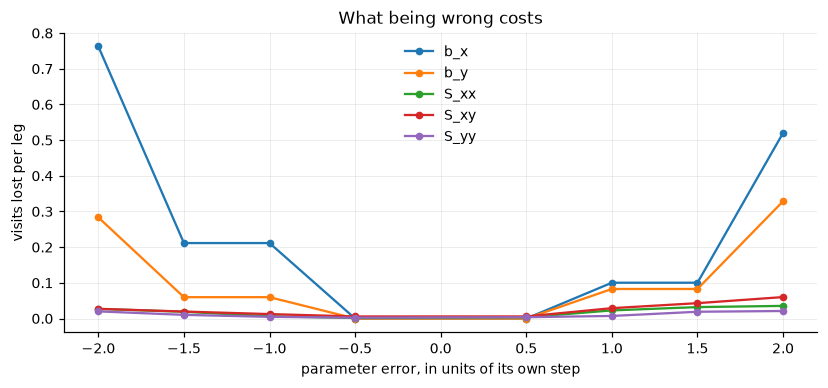

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 3.6))
for i, p in enumerate(PARAMS):
    xs, ys = dw[f'profile_x_{p}'], dw[f'profile_y_{p}']
    o = np.argsort(xs)
    ax.plot(xs[o] / step[i], ys[o], 'o-', ms=4, label=p)
ax.set_xlabel('parameter error, in units of its own step')
ax.set_ylabel('visits lost per leg')
ax.set_title('What being wrong costs')
ax.legend()
fig.tight_layout()

**The pull is worth about twenty times the shape.** Three millimetres of sideways bias costs
0.139 visits a leg; a millimetre and a half on $\sigma_y$ costs 0.006. Everything the last
three notebooks added to the *shape* of the throw is, from the policy's point of view, a
rounding error next to knowing where the player's darts actually centre.

Two details worth pulling out of the table.

**Sideways bias costs twice what vertical bias does** -- 0.139 against 0.066. This is the
same asymmetry notebook 16 found from the other side: at the top of the board a vertical
error is radial and drops you from the treble 20 into the single 20, while a horizontal error
is tangential and drops you into the 1 or the 5. The board punishes sideways error, so it
punishes sideways *misjudgement* too.

**The lean outranks both individual spreads** -- $\Sigma_{xy}$ at 0.012 against 0.009 and
0.006. That is not what I would have guessed, and it is consistent with notebook 16's finding
that rotating a fixed ellipse moves the value by more than changing its shape does.

So a design that spends its darts measuring $\sigma$ precisely, which is exactly what notebook
09's design does, is optimising the least valuable coordinate.

### An aside that is not an aside: the loss is a staircase

Look at the $b_x$ profile. An error of half a step costs **exactly zero**, and errors of one
step and one and a half steps cost the *same*. That is not noise.

The recommender chooses from a finite grid of aiming points, 3.52 mm apart here. A parameter
error small enough to leave every recommendation unchanged costs nothing at all, and the
loss then climbs in steps as, one by one, the recommended points move. There is a resolution
below which measuring a player better buys **nothing**, and it is set by how finely the
system can aim rather than by how much data was collected.

(This is why the Hessian's diagonal is fitted by least squares through several perturbation
sizes rather than by one central difference, which would report where the grid points happen
to fall.)

## Three designs

Now the search, over the same candidate grid, with three criteria: the old one, and the two
new ones.

In [4]:
c_sigma = sigma_gradient(S_TRUE)
designs = {}
t0 = time.perf_counter()
designs['c: sigma only (notebook 09)'] = optimal_design_general(I_PTS, kind='c', c=c_sigma)
designs['D: best overall fit'] = optimal_design_general(I_PTS, kind='D')
designs['L: best overall scores'] = optimal_design_general(I_PTS, kind='L', W=H)
print(f'three designs in {time.perf_counter()-t0:.0f}s')

rows = []
for name, d in designs.items():
    w = d['weights']
    keep = np.argsort(-w)[:6]
    keep = [k for k in keep if w[k] > 0.01]
    rows.append({'design': name, 'support': int(len(d['support'])),
                 'certificate': d['certificate'],
                 'targets (weight)': ', '.join(
                     f'{aim_description(CAND[k], PX)} @{np.hypot(*((CAND[k]-CENTRE)*MM)):.0f}mm'
                     f' ({w[k]:.0%})' for k in keep)})
pd.DataFrame(rows).set_index('design')

three designs in 13s


,support,certificate,targets (weight)
design,,,
c: sigma only (notebook 09),7,1.00000,"12 @139mm (33%), 2 @139mm (30%), 13 @137mm (21..."
D: best overall fit,3,1.00000,BULL @0mm (100%)
L: best overall scores,11,1.00005,"25 @8mm (80%), 25 @11mm (18%), 25 @13mm (1%)"


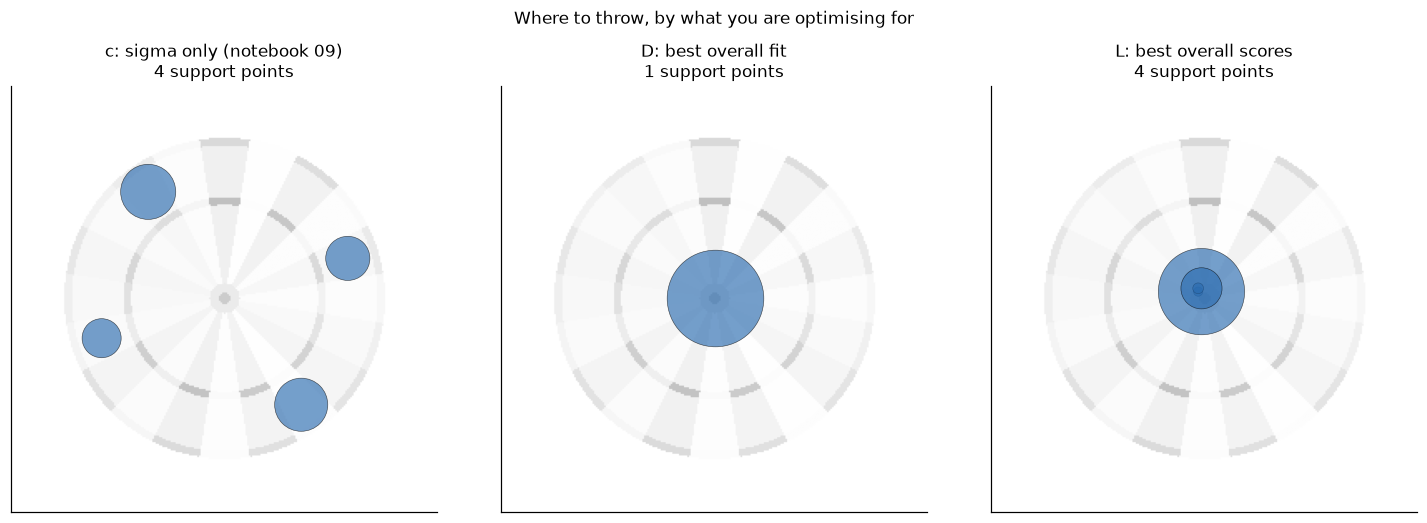

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, (name, d) in zip(axes, designs.items()):
    w = d['weights']
    ax.imshow(BOARD, origin='lower', cmap='Greys', alpha=0.25)
    big = w > 1e-3
    ax.scatter(CAND[big, 1], CAND[big, 0], s=4000 * w[big], alpha=0.65,
               color='#2b6cb0', edgecolor='k', linewidth=0.4)
    ax.set_title(f'{name}\n{int(big.sum())} support points')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle('Where to throw, by what you are optimising for', y=1.02)
fig.tight_layout()

The three criteria give three genuinely different answers, and all three are certified optimal
(the equivalence-theorem certificate is 1 at the optimum and above 1 everywhere else).

* **c-optimal for $\sigma$** spreads seven points around the **137--139 mm ring**, which is
  notebook 09's answer recovered exactly -- the outer single ring, where a change of spread
  most changes how often you fall off the board's scoring structure.
* **D-optimal** collapses onto **the bull, at a single point with all the weight**.
* **L-optimal for scoring** also goes to the middle, but not quite to the centre: 80% of its
  weight sits **8 mm out**, on the ring just outside the 50.

Two things are worth stopping on.

**A single target can be D-optimal for five parameters.** That looks impossible -- one design
point normally gives a rank-1 information matrix -- and it is possible here because a throw
does not return a number, it returns a *category*. One dart at the bull can land in the 50,
the 25, or any of twenty segments beyond it, and the multinomial over those outcomes carries
information about all five parameters at once. The board does the job that replication at
different points would have to do otherwise.

**The 8 mm offset is not noise.** The inner bull ends at 6.35 mm, so the L-design is sitting
just *outside* that boundary, on the steepest part of the 50/25 edge. Bias is a translation,
and a translation is most visible where moving the group across a boundary changes the
outcome fastest. Since bias is what the policy cares about most, the decision-weighted design
buys sensitivity to translation at a small cost in everything else.

### Do they actually disagree?

Three designs that look different might still be near-interchangeable in practice. Score
each one under every criterion, relative to the design built for it.

In [6]:
def value_of(w_design, kind, c=None, W=None):
    M = np.tensordot(w_design, I_PTS, axes=(0, 0))
    if kind == 'D':
        return -np.linalg.slogdet(M)[1]
    if kind == 'c':
        return c_criterion(M, c)
    return l_criterion(M, W)

crits = [('c: sigma only', 'c', c_sigma, None),
         ('D: overall fit', 'D', None, None),
         ('L: overall scores', 'L', None, H)]
rows = []
for dname, d in designs.items():
    row = {'design': dname}
    for cname, kind, c, W in crits:
        v = value_of(d['weights'], kind, c, W)
        best = value_of(designs[[k for k in designs if k.startswith(cname[0])][0]]['weights'],
                        kind, c, W)
        # D is a log-determinant, so efficiency is per-parameter and exponential
        row[cname] = (np.exp((best - v) / I_PTS.shape[1]) if kind == 'D'
                      else best / v)
    rows.append(row)
eff = pd.DataFrame(rows).set_index('design')
print('efficiency of each design under each criterion (1.00 = the best possible)')
eff.round(3)

efficiency of each design under each criterion (1.00 = the best possible)


,c: sigma only,D: overall fit,L: overall scores
design,,,
c: sigma only (notebook 09),1.000,0.581,0.484
D: best overall fit,0.618,1.000,0.971
L: best overall scores,0.550,0.949,1.000


This is the most practically useful table in the notebook, and it says two things.

**The old design is bad at the new job.** Notebook 09's $\sigma$-optimal session runs at
**48% efficiency** for scoring -- you would need roughly twice the darts to reach the same
place. It is not a small penalty, and the reason is the previous section: it spends its whole
budget on the coordinate worth least.

**The decision weighting barely matters.** D and L score 0.95 and 0.97 against each other.
That is a *negative* result and a welcome one: having gone to the trouble of measuring $H$
by simulation, the honest finding is that you did not need it. Plain **D-optimality -- a
standard criterion, no MDP solves, no Hessian -- gets you 97% of the way** to the
decision-optimal design.

The reason is that both criteria are dominated by the same thing. Bias is where the value is,
bias information is best near the centre, and both designs go there. The weighting changes
the fine positioning (dead centre against 8 mm out) and not the answer.

The converse is also worth noting: the designs built for scoring are poor at measuring
$\sigma$ (0.55 and 0.62). These really are different objectives. If you want to *track a
player's $\sigma$ over time* -- notebook 10's question -- you still want notebook 09's ring.
If you want to play better tonight, you want the bull.

## So what do I throw at, with N darts?

The optimal *proportions* do not depend on N -- only the precision they buy does. So the
answer to "what should I throw at" is one split, and the answer to "how many darts" is
whatever precision you want out of it.

Two things worth reading off: the expected visits per leg still lost to residual uncertainty
after a session of N darts, and the standard error on each parameter.

In [7]:
rows = []
for name, d in designs.items():
    M = np.tensordot(d['weights'], I_PTS, axes=(0, 0))
    Minv = np.linalg.inv(M)
    for N in (100, 200, 500, 1000):
        rows.append({'design': name, 'N darts': N,
                     'visits lost per leg': 0.5 * np.trace(H @ Minv) / N,
                     'SE b_x (mm)': np.sqrt(Minv[0, 0] / N),
                     'SE sigma (mm)': np.sqrt(c_criterion(M, c_sigma) / N),
                     'SE rho': np.sqrt(
                         (np.array([0, 0, -RHO / (2 * SX ** 2), 1 / (SX * SY),
                                    -RHO / (2 * SY ** 2)]) @ Minv @
                          np.array([0, 0, -RHO / (2 * SX ** 2), 1 / (SX * SY),
                                    -RHO / (2 * SY ** 2)])) / N)})
budget = pd.DataFrame(rows).set_index(['design', 'N darts'])
budget.round(4)

visits lost per leg  SE b_x (mm)  \
design                      N darts                                     
c: sigma only (notebook 09) 100                   0.1755       2.3836   
                            200                   0.0877       1.6855   
                            500                   0.0351       1.0660   
                            1000                  0.0175       0.7538   
D: best overall fit         100                   0.0875       1.5581   
                            200                   0.0438       1.1017   
                            500                   0.0175       0.6968   
                            1000                  0.0088       0.4927   
L: best overall scores      100                   0.0850       1.5581   
                            200                   0.0425       1.1017   
                            500                   0.0170       0.6968   
                            1000                  0.0085       0.4927   

                                     SE sigma (mm)  SE rho  
design                      N darts                         
c: sigma only (notebook 09) 100             1.0716  0.1791  
                            200             0.7577  0.1267  
                            500             0.4792  0.0801  
                            1000            0.3389  0.0566  
D: best overall fit         100             1.3632  0.1187  
                            200             0.9639  0.0840  
                            500             0.6096  0.0531  
                            1000            0.4311  0.0375  
L: best overall scores      100             1.4454  0.1224  
                            200             1.0220  0.0866  
                            500             0.6464  0.0547  
                            1000            0.4571  0.0387

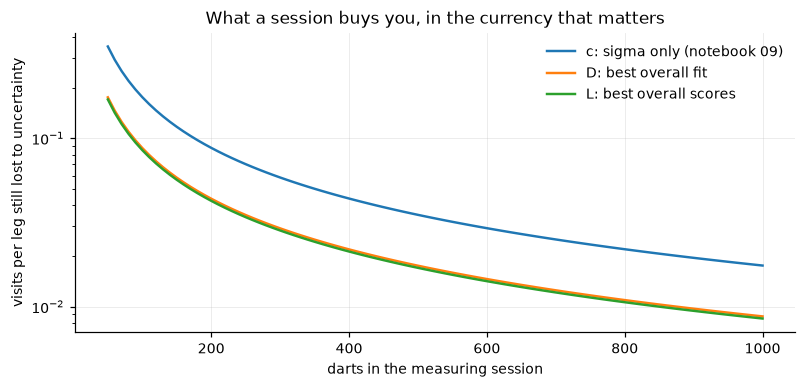

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
for name, d in designs.items():
    M = np.tensordot(d['weights'], I_PTS, axes=(0, 0))
    loss = 0.5 * np.trace(H @ np.linalg.inv(M))
    Ns = np.arange(50, 1001, 10)
    ax.plot(Ns, loss / Ns, lw=1.6, label=name)
ax.set_xlabel('darts in the measuring session')
ax.set_ylabel('visits per leg still lost to uncertainty')
ax.set_yscale('log')
ax.set_title('What a session buys you, in the currency that matters')
ax.legend()
fig.tight_layout()

The practical answer, then. **Throw at the bull, and 200 darts is plenty.**

At 200 darts the L-optimal session leaves **0.043 visits per leg** on the table, and the
figure is worth putting next to what the model gained by getting richer at all: 0.27 visits
for modelling anisotropy (notebook 12), 0.91 for modelling the pull (13), 0.12 for the lean
(16). Residual estimation error at 200 darts is already an order of magnitude below the
things it lets you model. Going to 1000 darts buys another 0.034 visits a leg, which is real
but small, and the staircase from earlier says some of it is not there at all.

The old $\sigma$-design needs about **twice the darts** for the same scoring outcome --
0.0877 at 200 against 0.0438, and 0.0438 is what the bull reaches at 200. Efficiency ratios
turn straight into dart counts, which is the useful way to read them.

The columns also show why the criteria disagree. The $\sigma$-design measures $\sigma$ better
at every budget (0.76 mm against 1.02 at 200 darts) and measures **bias** and **$\rho$** much
worse (1.69 mm against 1.10; 0.127 against 0.087). It wins the contest it was built for and
loses the one that pays.

## Could a match do this instead?

Notebook 11 established that ordinary play measures $\sigma$ for free, and notebook 13 that
it measures the *pull* better than a drill does, because the policy varies the targets by
itself. The obvious hope is that it measures everything.

The reason to doubt it, for the lean specifically: notebook 16 found that $\rho$ is measured
at the **bull**, because that is where all twenty segment boundaries meet and angular
structure is finest. A match does not send you to the bull. So the first thing to check is
simply where a match *does* send you.

32 MDPs solved in 135s


1091 darts of match play
darts aimed within 20mm of the bull: 5 (0.5%)


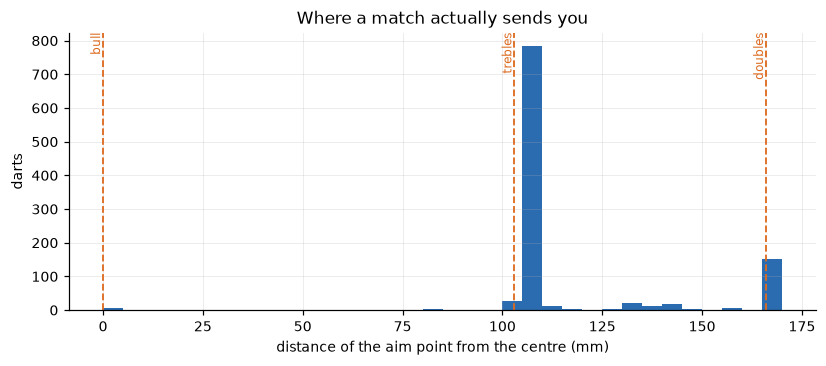

In [9]:
SOLVE, _ = sigma_matrices([11.0, 14.0, 18.0, 22.0], [11.0, 14.0, 18.0, 22.0],
                          [-0.2, 0.2])
t0 = time.perf_counter()
rec = ShapeRecommender(SOLVE, board_pixels=PX, point_stride=2)
print(f'{len(rec.models)} MDPs solved in {time.perf_counter()-t0:.0f}s')

rng = np.random.default_rng(4)
pf = ParticleThrowPosterior(300, band='league', tilt=True, board=rec.board,
                            checkouts=rec.checkouts, rng=np.random.default_rng(5))
log = []
for _ in range(40):
    play_leg(rec, pf, S_TRUE, np.zeros(2), rng, policy=(S_TRUE, np.zeros(2)),
             record=log)
hist = pd.DataFrame(log)
r_aim = np.hypot(hist.aim_row - CENTRE, hist.aim_col - CENTRE) * MM
print(f'{len(hist)} darts of match play')

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.hist(r_aim, bins=np.arange(0, 175, 5), color='#2b6cb0')
for r, lab in [(0, 'bull'), (103, 'trebles'), (166, 'doubles')]:
    ax.axvline(r, color='#dd6b20', ls='--', lw=1.2)
    ax.annotate(lab, (r, ax.get_ylim()[1]), rotation=90, fontsize=8,
                va='top', ha='right', color='#dd6b20')
ax.set_xlabel('distance of the aim point from the centre (mm)')
ax.set_ylabel('darts')
ax.set_title('Where a match actually sends you')
fig.tight_layout()

print(f'darts aimed within 20mm of the bull: {(r_aim < 20).sum()} '
      f'({100*(r_aim < 20).mean():.1f}%)')

**Half a percent.** Five darts in a thousand are aimed within 20 mm of the centre.

The histogram is essentially two spikes -- the treble ring at about 103 mm, where the scoring
darts go, and the double ring at 166 mm, where the finishing darts go -- and almost nothing in
between or inside. That is not an accident of this player: it is what a scoring game is. You
are paid to be at the outside of the board, and the middle is only ever a checkout target.

So a match cannot send you where the lean is measured. Notebook 16 found the bull to be the
right target for $\rho$ precisely because all twenty segment boundaries meet there, and match
play visits that region essentially never. Whatever a match teaches you about the lean, it
teaches from the trebles, which notebook 16 measured as about ten times worse per dart.

In [10]:
# how well is each parameter learned, match play against the designed session?
L_TRUE = np.linalg.cholesky(S_TRUE)
N_DARTS, N_SEEDS = 600, 40

def learn_match(seed):
    pf = ParticleThrowPosterior(400, band='league', tilt=True, board=rec.board,
                                checkouts=rec.checkouts,
                                rng=np.random.default_rng(700 + seed))
    rng = np.random.default_rng(seed)
    while pf.n_updates < N_DARTS:
        play_leg(rec, pf, S_TRUE, np.zeros(2), rng, policy=(S_TRUE, np.zeros(2)))
    return pf

def learn_design(seed, weights):
    '''Throw the designed session: sample targets in proportion to the design.'''
    pf = ParticleThrowPosterior(400, band='league', tilt=True, board=BOARD,
                                checkouts=CHECKOUTS,
                                rng=np.random.default_rng(700 + seed))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(CAND), size=N_DARTS, p=weights / weights.sum())
    for j in idx:
        t = (CAND[j] - CENTRE)[::-1] * MM          # (row, col) -> (x, y) mm
        land = t + L_TRUE @ rng.standard_normal(2)
        col = int(round(land[0] / MM)) + CENTRE
        row = int(round(land[1] / MM)) + CENTRE
        v = int(BOARD[row, col]) if 0 <= row < PX and 0 <= col < PX else 0
        pf.update(t, v, pixel=False)
    return pf

THETA_TRUE = np.array([0.0, 0.0, SX ** 2, RHO * SX * SY, SY ** 2])

def theta_of(pf):
    sx, sy = pf.mean_sigma_xy()
    b = pf.mean_bias()
    return np.array([b[0], b[1], sx ** 2, pf.mean_rho() * sx * sy, sy ** 2])

sessions = {
    'match play': learn_match,
    'the L-optimal session':
        lambda s: learn_design(s, designs['L: best overall scores']['weights']),
    'the D-optimal session':
        lambda s: learn_design(s, designs['D: best overall fit']['weights']),
}
fits = {}
for label, maker in sessions.items():
    fits[label] = np.array([theta_of(maker(s)) for s in range(N_SEEDS)])

def visit_cost(th):
    d = th - THETA_TRUE
    return 0.5 * np.einsum('ni,ij,nj->n', d, H, d)

rows = []
for label, th in fits.items():
    sx = np.sqrt(th[:, 2]); sy = np.sqrt(th[:, 4])
    rho = th[:, 3] / (sx * sy)
    cost = visit_cost(th)
    rows.append({'session': label,
                 'sigma_x (truth 14)': sx.mean(),
                 'sigma_y (truth 18)': sy.mean(),
                 'rho (truth 0.2)': rho.mean(),
                 'rmse of rho': np.sqrt(np.mean((rho - RHO) ** 2)),
                 'rmse of bias (mm)': np.sqrt(np.mean((th[:, :2]) ** 2)),
                 'visits lost per leg': cost.mean(),
                 '+/-': cost.std(ddof=1) / np.sqrt(N_SEEDS)})
print(f'{N_SEEDS} runs of {N_DARTS} darts each')
pd.DataFrame(rows).set_index('session').round(3)

40 runs of 600 darts each


,sigma_x (truth 14),sigma_y (truth 18),rho (truth 0.2),rmse of rho,rmse of bias (mm),visits lost per leg,+/-
session,,,,,,,
match play,14.142,17.562,0.140,0.149,1.467,0.068,0.010
the L-optimal session,14.552,17.895,0.177,0.073,1.276,0.039,0.005
the D-optimal session,14.354,17.684,0.173,0.076,1.182,0.039,0.006


In [11]:
# The seeds are shared, so compare the sessions *paired* -- far tighter than
# differencing two independent means.
base = visit_cost(fits['match play'])
for label in ('the L-optimal session', 'the D-optimal session'):
    diff = base - visit_cost(fits[label])
    se = diff.std(ddof=1) / np.sqrt(N_SEEDS)
    print(f'match play costs {diff.mean():+.4f} +/- {se:.4f} visits per leg '
          f'more than {label}')

match play costs +0.0294 +/- 0.0125 visits per leg more than the L-optimal session
match play costs +0.0285 +/- 0.0133 visits per leg more than the D-optimal session


Match play learns most of it, and misses the lean.

On **bias** the two are close: 1.47 mm of error from a match against 1.28 mm from the designed
session. That is notebook 13's finding holding up under a richer model -- the policy moves the
target around by itself, and a target that moves is a target that reveals a translation.
On **the spreads** they are close too, both a little low, and both sessions shrink $\sigma_y$
toward the prior in the same way, so that is the prior's doing rather than the match's.

On **the lean** they part company. The designed session pins $\rho$ to an RMSE of 0.073; the
match manages 0.149, twice as poor, and its mean estimate has slid to 0.140 against a truth
of 0.2 -- shrunk back toward a prior centred on no lean, because the trebles and doubles
simply are not telling it much. This is the histogram above, cashed out: the information about
orientation lives at the centre, and matches happen at the edge.

The last column is the one to read, and it is the point of the whole notebook: it takes each
session's *actual* estimation errors and prices them, through $H$, in the currency the player
cares about. Two sessions can differ a lot in how well they pin $\rho$ and hardly at all in
what that costs.

## Is it worth breaking off to measure?

If a match cannot teach you the lean, the question becomes whether it is worth *interrupting*
one -- throwing some darts at the bull, deliberately, at a cost in immediate score, to learn
a parameter that then improves every subsequent leg.

That is a value-of-information calculation with a clean break-even. Throwing $m$ darts at the
bull instead of at the shot the policy wants costs the difference in their immediate value;
learning the parameter is worth the visits it saves thereafter.

In [12]:
# what does a bull dart cost, against playing the shot the policy wants?
k = rec.nearest_sigma(S_TRUE)
bull_idx = int(np.argmin(np.hypot(CAND[:, 0] - CENTRE, CAND[:, 1] - CENTRE)))
# match the bull to the recommender's own candidate set
rec_bull = int(np.argmin(np.hypot(rec.points[:, 0] - CENTRE, rec.points[:, 1] - CENTRE)))
costs = []
for score in (501, 301, 180, 120, 81):
    q = rec.models[k].q_values(score, 1, score)
    costs.append(q.max() - q[rec_bull])
cost_per_bull_dart = float(np.mean(costs))
print(f'a dart at the bull instead of the best shot costs '
      f'{cost_per_bull_dart:.4f} visits, averaged over scoring states')

M_L = np.tensordot(designs['L: best overall scores']['weights'], I_PTS, axes=(0, 0))
Minv_L = np.linalg.inv(M_L)
rows = []
for m in (0, 25, 50, 100, 200, 400):
    explore = m * cost_per_bull_dart          # paid once, in visits
    resid = (0.5 * np.trace(H @ Minv_L) / m) if m else np.nan
    rows.append({'darts spent measuring': m,
                 'one-off cost (visits)': explore,
                 'residual loss (visits per leg)': resid,
                 'legs to repay': explore / resid if m else np.nan})
pd.DataFrame(rows).set_index('darts spent measuring').round(3)

a dart at the bull instead of the best shot costs 0.0644 visits, averaged over scoring states


,one-off cost (visits),residual loss (visits per leg),legs to repay
darts spent measuring,,,
0,0.000,NaN,NaN
25,1.611,0.340,4.737
50,3.222,0.170,18.949
100,6.444,0.085,75.797
200,12.888,0.043,303.186
400,25.777,0.021,1212.745


A dart thrown at the bull instead of at the shot the policy wants costs **0.064 visits**,
averaged over scoring states. That is the price of exploring, and it is not nothing: about
one visit for every fifteen darts diverted.

Read the table as a break-even and it looks discouraging, and the discouragement is partly an
artefact of the framing. "Legs to repay" *grows* with the budget -- 4.7 legs for 25 darts,
1213 for 400 -- because the cost is linear in the darts and the benefit falls as $1/n$. Any
budget repays eventually; larger budgets take longer to repay and leave you better off once
they have. The table cannot say which budget is right, because it never fixed how long you
intend to play.

"Legs to repay" is the wrong question asked slightly the wrong way, because it grows with the
budget and so makes *any* measuring look like a bad idea if you measure enough. The right
question fixes a horizon. Over $L$ legs, spending $m$ darts costs

$$m\,c_{\text{explore}} \;+\; L\,K/m, \qquad K = \tfrac{1}{2}\mathrm{tr}(H M^{-1}),$$

which is smallest at $m^\star = \sqrt{L K / c_{\text{explore}}}$ -- the classic square root.

In [13]:
K = 0.5 * np.trace(H @ Minv_L)
rows = []
for L_legs in (10, 50, 100, 500, 2000):
    m_star = np.sqrt(L_legs * K / cost_per_bull_dart)
    total = m_star * cost_per_bull_dart + L_legs * K / m_star
    rows.append({'legs you will play': L_legs,
                 'best measuring budget (darts)': m_star,
                 'total visits paid': total,
                 'as a fraction of a leg': total / L_legs})
print(f'K = {K:.3f} visits-legs, exploration costs {cost_per_bull_dart:.4f} visits/dart')
pd.DataFrame(rows).set_index('legs you will play').round(3)

K = 8.502 visits-legs, exploration costs 0.0644 visits/dart


,best measuring budget (darts),total visits paid,as a fraction of a leg
legs you will play,,,
10,36.322,4.681,0.468
50,81.219,10.468,0.209
100,114.862,14.804,0.148
500,256.839,33.102,0.066
2000,513.677,66.205,0.033


Fixing the horizon makes it well posed. For a hundred legs -- a season of club darts -- the
best budget is about **115 darts**, and the whole exercise costs **0.148 visits per leg**
amortised. For ten legs it is 36 darts, for two thousand it is 514.

The square root is doing something reassuring here: the budget grows much more slowly than
the horizon, so the answer is fairly insensitive to guessing how much you will play. Anything
between about 50 and 250 darts is within a whisker of optimal for any plausible horizon.

### The comparison that actually decides it

The table above quietly assumes the alternative to measuring is knowing nothing. It is not:
a match teaches you most of this for free. The honest marginal question is whether deliberate
bull darts beat what match play gives you anyway -- and that gap was measured two sections
ago.

In [14]:
gap = (visit_cost(fits['match play'])
       - visit_cost(fits['the L-optimal session'])).mean()
one_off = N_DARTS * cost_per_bull_dart
print(f'the designed session is worth {gap:.4f} visits per leg over match play')
print(f'buying it mid-match costs {N_DARTS} x {cost_per_bull_dart:.4f} '
      f'= {one_off:.1f} visits, once')
print(f'-> it repays after {one_off / gap:.0f} legs')
print()
print(f'buying it in *practice* costs nothing in match terms, '
      f'and pays {gap:.4f} visits per leg from the first leg on')

the designed session is worth 0.0294 visits per leg over match play
buying it mid-match costs 600 x 0.0644 = 38.7 visits, once
-> it repays after 1316 legs

buying it in *practice* costs nothing in match terms, and pays 0.0294 visits per leg from the first leg on


**Deliberately measuring mid-match is not worth it.** Six hundred diverted darts cost 38.7
visits up front and buy 0.029 visits a leg, which takes **about 1300 legs** to repay. That
conclusion is robust to the uncertainty in the gap: even taking the optimistic end of
$0.029 \pm 0.013$, the answer is still hundreds of legs. Nobody is playing a thousand legs
against the same version of themselves -- the player will have changed first, which is
precisely what notebook 10 was about.

**Measuring in practice is worth it,** for the boring reason that practice darts are not
scoring darts. There is no 0.064 visits to pay, so the 0.029 visits a leg is free from the
first leg on.

The gap itself is real but modest: 0.029 visits per leg, at 2.4 standard errors over 40 runs.
It would be overstating it to call the difference decisive, and understating it to ignore the
direction, which is consistent across both designed sessions.

## Verdict

### Where should I throw, with N darts?

**At the bull.** For all five parameters at once, D-optimality puts every dart on the centre,
and the decision-weighted design puts 80% of them on the ring 8 mm out, just outside the 50.
Two hundred darts leaves about **0.043 visits per leg** on the table, which is already well
below what the shape, the pull and the lean are individually worth -- so 200 is a sensible
session and 1000 is diminishing returns.

This is a different answer from notebook 09's, which sent you to the 137 mm ring, and notebook
09 was not wrong -- it was answering a different question. Its design is **48% efficient** for
scoring, needing twice the darts, because it spends them measuring the coordinate that matters
least.

### Weighted how?

**It hardly matters, and that is worth knowing.** Plain D-optimality reaches 97% of the
decision-optimal design's value. The Hessian $H$ took a few hundred MDP solves to estimate and
the honest conclusion is that you can skip it: both criteria are dominated by bias, bias
information lives at the centre, and both go there.

$H$ still earned its place, in what it revealed rather than what it changed. The pull is worth
**twenty times** the shape, sideways pull twice vertical, and the lean more than either
individual spread.

### Can a match do it instead?

**Mostly.** A match measures the bias almost as well as a designed session (1.47 mm against
1.28 mm) and the spreads about as well. It measures the **lean** twice as poorly, and biases
it toward zero, because $\rho$ is read from angular structure, angular structure is finest at
the centre, and **0.5%** of match darts are aimed anywhere near the centre.

In the currency that matters, a match leaves you **0.068** visits per leg against a designed
session's **0.039** -- a gap of $0.029 \pm 0.013$. Both numbers are small.

### Is it worth it?

**In practice, yes. Mid-match, no.** Diverting darts to the bull costs 0.064 visits each, and
600 of them take about 1300 legs to repay. Practice darts cost nothing in match terms, so the
same session is free there.

### Do we need to adapt the particle sampler?

**No -- and that is the real finding of the second half.** The five-parameter filter from
notebook 16 handles all of this unchanged: it tracks $\Sigma$ and $b$ jointly, it runs at
millisecond speed, and it needs no new machinery to be given bull darts instead of treble
darts. Nothing about the *inference* is the bottleneck.

What is missing is not a better estimator but different **data**. The policy will never send
the player to the centre, because the centre is a bad place to score from, so the information
the filter needs is information the game will not generate. That is a policy problem -- an
exploration problem -- and the exploration is not worth paying for mid-match.

So: **a live recommendation system works, and it should not try to be clever.** Run the
particle filter during play; it will pin down the bias and the spreads by itself within a few
hundred darts, which is where nearly all of the value is. Leave the lean to a practice session
at the bull, or to a prior.

### What this leaves

* **$H$ was measured for one player.** The importance ordering -- bias twenty times the shape
  -- may well change for a very tight or very loose player, where the policy's sensitivity to
  each parameter is different. The design would then move.
* **The staircase deserves following up.** The value loss is flat below half an aiming-grid
  step, so there is a precision beyond which measurement buys literally nothing. That bound
  comes from the aiming grid, not the data, and nobody has asked what the grid *should* be.
* **The exploration question was answered, not optimised.** Comparing "all bull" against "no
  bull" is not the same as solving for the best mixture of scoring and exploring darts, which
  is a genuine dual-control problem and out of scope here.
* **The match-play comparison uses a player who does not change.** If the player drifts, the
  case for continuous measurement gets stronger and the case for a one-off practice session
  gets weaker; the drift-aware filter from notebook 15 exists but has not been pointed at this
  question.